In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from concept_abstraction.plotting import *
from concept_abstraction.utils import *
import matplotlib.lines as mlines
from concept_abstraction.concept_bank import get_all_mini_grid_names
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
style_size = 'paper'

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [3]:
# ── Shared config ─────────────────────────────────────────────────────────────
training_times = {
    'cart_pole': 4_000_000,
    'mini_grid': 500_000,
    'glucose':   4_000_000,
    'pong':      15_000_000,
    'boxing':    15_000_000,
}

In [4]:
gold_timesteps = {
    'cart_pole': 4_000_000,
    'mini_grid': 1_000_000,
    'glucose':   4_000_000,
    'pong':      15_000_000,
    'boxing':    30_000_000,
}

In [5]:
name_to_nice = {
    'cart_pole': "CartPole",
    'mini_grid': "MiniGrid",
    'glucose':   'Glucose',
    'pong':      "Pong",
    'boxing':    "Boxing",
}

In [6]:
# Single source of truth for display names
METHOD_DISPLAY = {
    'random':      'Random',
    'variance':    'Variance',
    'greedy':      'Greedy',
    'drs':         'DRS',
    'drs_log':     'DRS-Log',
    'drs_no_relax': 'Non-Relax.',
    'drs_rho_0':   r'$\rho=0$',
    'drs_rho_05':  r'$\rho=0.5$',
    'drs_rho_099': r'$\rho=0.99$',
    'all_concepts': 'All Concepts',
}

In [7]:
# Integer-keyed version for plot_bar (used in Figure 2, timing)
methods_dict = {
    0: 'Random',
    1: 'Variance',
    2: 'Greedy',
    3: 'DRS',
    4: 'DRS-Log',
}

In [8]:
num_concepts_per_env = {
    'cart_pole': 3,
    'mini_grid': 11,
    'pong':      57,
    'boxing':    48,
    'glucose':   10,
}

In [9]:
method_scales = [
    lambda d: d / 500 * 100,
    lambda d: d / 1 * 100,
    lambda d: (d + 21) / 42 * 100,
    lambda d: d / 100 * 100,
    lambda d: (d + 20) / (40 + 20) * 100,
]
method_scales_std = [
    lambda d: d / 500 * 100,
    lambda d: d / 1 * 100,
    lambda d: d / 42 * 100,
    lambda d: d / 100 * 100,
    lambda d: d / (40 + 20) * 100,
]

In [10]:
# ── Figure 2: Main comparison ─────────────────────────────────────────────────
perfect_environments  = ['cart_pole', "mini_grid", "pong", "boxing", "glucose"]
perfect_methods       = ["all_concepts", "random", "variance", "greedy", "drs"]

In [11]:
imperfect_environments = ['cart_pole', "mini_grid", "pong", "boxing"]
imperfect_methods      = ["all_concepts", "random", "variance", "greedy", "drs", "drs_log"]

In [12]:
all_performances_perfect      = []
all_performances_perfect_std  = []
all_performances_imperfect     = []
all_performances_imperfect_std = []
all_baselines = []

In [13]:
for j, e in enumerate(perfect_environments):
    temp, temp_std = [], []
    for m in perfect_methods:
        matching_params = get_results_matching_parameters(
            "basic", "",
            {'environment_string': e, 'training_timesteps': training_times[e],
             'num_concepts_selected': num_concepts_per_env[e],
             'setting':'perfect',
             'method': m, 'gold_timesteps': gold_timesteps[e]})
        print("Perfect", e, m, len(matching_params),
              [(i[m]['reward'], i['parameters']['seed'], i[m]['concepts'])
               for i in matching_params if m in i])
        vals = [i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]
        temp.append(method_scales[j](np.mean(vals)))
        temp_std.append(method_scales_std[j](np.std(vals)) / len(vals) ** 0.5)
    all_performances_perfect.append(temp)
    all_performances_perfect_std.append(temp_std)

Perfect cart_pole all_concepts 6 [(500.0, 45, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.655, 47, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.915, 43, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.5, 42, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (500.0, 46, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (499.875, 44, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])]
Perfect cart_pole random 6 [(172.8411867364747, 43, [0, 9, 10]), (174.26186291739896, 45, [0, 9, 10]), (173.9106830122592, 44, [0, 9, 10]), (172.74434782608697, 46, [0, 9, 10]), (171.32413793103447, 42, [0, 9, 10]), (173.65034965034965, 47, [0, 9, 10])]
Perfect cart_pole variance 6 [(122.23645320197045, 43, [4, 9, 3]), (122.98019801980197, 44, [4, 3, 9]), (126.8764331210191, 47, [10, 3, 4]), (325.8973509933775, 46, [10, 3, 9]), (117.70567375886525, 45, [3, 4, 10]), (286.7325581395349, 42, [10, 9, 3])]
Perfect cart_pole greedy 6 [(326.2119205298013, 44, [10, 3, 9]), (167.77871621621622, 46, [10, 9, 0]), (110.20066518847007, 47, [4, 10,

In [14]:
for j, e in enumerate(imperfect_environments):
    temp, temp_std = [], []
    for m in imperfect_methods:
        matching_params = get_results_matching_parameters(
            "basic", "",
            {'environment_string': e, 'training_timesteps': training_times[e],
             'num_concepts_selected': num_concepts_per_env[e],
             'setting':'imperfect',
             'method': m, 'gold_timesteps': gold_timesteps[e]})
        print("Imperfect", e, m, len(matching_params),
              [(i[m]['reward'], i['parameters']['seed'], i[m]['concepts'])
               for i in matching_params if m in i])
        vals = [i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]
        temp.append(method_scales[j](np.mean(vals)))
        temp_std.append(method_scales_std[j](np.std(vals)) / len(vals) ** 0.5)
        if m == 'drs_log':
            print("  concept_accuracy:", [i['concept_accuracy'] for i in matching_params])
    all_performances_imperfect.append(temp)
    all_performances_imperfect_std.append(temp_std)

Imperfect cart_pole all_concepts 6 [(383.16796875, 42, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (498.765, 47, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (404.50409836065575, 43, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (481.6078431372549, 45, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (472.6019417475728, 46, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]), (428.0305676855895, 44, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])]
Imperfect cart_pole random 6 [(80.99918765231519, 44, [0, 9, 10]), (70.50247699929228, 43, [0, 9, 10]), (96.16216216216216, 47, [0, 9, 10]), (91.35321100917432, 46, [0, 9, 10]), (91.4954128440367, 42, [0, 9, 10]), (78.28031496062992, 45, [0, 9, 10])]
Imperfect cart_pole variance 6 [(103.40602284527519, 46, [10, 3, 9]), (99.3562874251497, 47, [10, 3, 4]), (94.5127962085308, 44, [4, 3, 9]), (115.49361207897793, 42, [10, 9, 3]), (87.43195785776997, 43, [4, 9, 3]), (84.42408821034775, 45, [3, 4, 10])]
Imperfect cart_pole greedy 6 [(103.22510373443983, 47, [4, 10, 3]), (94.5597722960151

In [15]:
for j, e in enumerate(perfect_environments):
    matching_params = get_results_matching_parameters(
        "training", "",
        {'environment_string': e, 'gold_timesteps': gold_timesteps[e]})
    m = 'ground_truth'
    print("Baseline", e, m, len(matching_params),
          [(i[m]['reward'], i['parameters']['seed']) for i in matching_params if m in i])
    vals = [i[m]['reward'] for i in matching_params if m in i and not np.isnan(i[m]['reward'])]
    all_baselines.append(method_scales[j](np.mean(vals)))

Baseline cart_pole ground_truth 6 [(494.375, 45), (499.485, 42), (493.43, 43), (499.455, 47), (491.90547263681594, 46), (497.73, 44)]
Baseline mini_grid ground_truth 6 [(0.9555648758799555, 42), (0.9612497038871541, 44), (0.9555967427513881, 45), (0.9612518255250404, 47), (0.9613703306139975, 43), (0.9555742222222222, 46)]
Baseline pong ground_truth 6 [(20.839285714285715, 47), (20.732142857142858, 44), (20.7, 46), (20.625, 43), (20.875, 42), (20.9, 45)]
Baseline boxing ground_truth 6 [(99.77358490566037, 46), (99.96923076923076, 44), (99.87421383647799, 45), (99.92307692307692, 43), (99.88125, 42), (99.9, 47)]
Baseline glucose ground_truth 6 [(26.149758225547895, 44), (36.734071989773625, 47), (11.022586252532555, 42), (44.92221607855823, 43), (8.014451287497979, 46), (99.41039132078564, 45)]


In [16]:
# Perfect setting plot
plot_dimensions = (1, len(perfect_environments))
titles   = [[name_to_nice[i] for i in perfect_environments]]
y_labels = [["" for i in range(len(perfect_environments))]]
y_labels[0][0] = "Perfect"

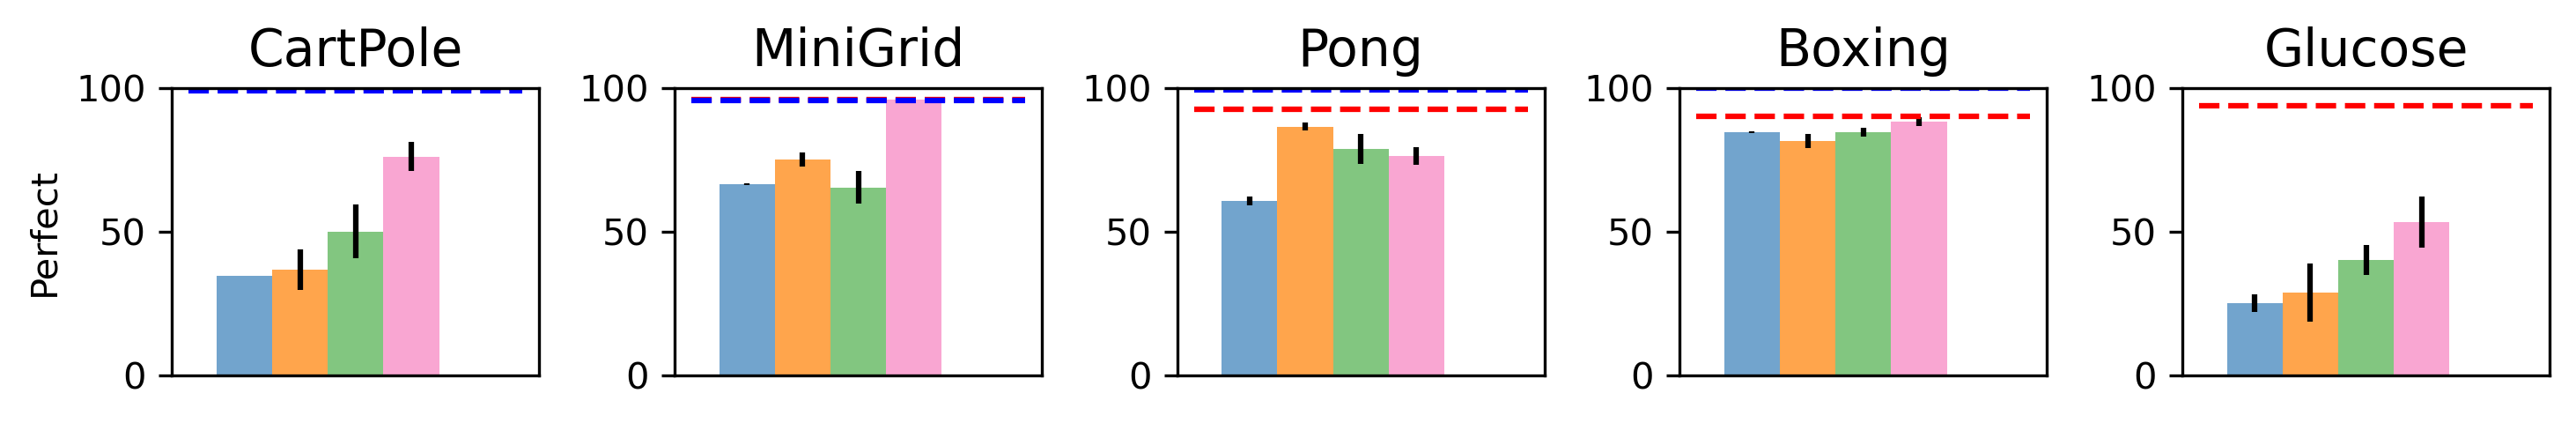

In [17]:
overall_format = {
    'figsize': (10, 2), 'style_size': style_size, 'has_grid': False,
    'y_lim':   [[[0, 100] for _ in range(5)]],
    'x_ticks': [[[[],[]] for _ in range(5)]],
}
fig, ax = create_axes(plot_dimensions, overall_format, titles=titles, y_labels=y_labels)
bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size}
for i in range(len(perfect_environments)):
    y_vals = all_performances_perfect[i][1:]
    y_std  = all_performances_perfect_std[i][1:]
    plot_bar(ax[0][i], list(range(len(y_vals))), y_vals, y_std, methods_dict, bar_format)
    ax[0][i].hlines(all_performances_perfect[i][0], -0.25, 1.25,
                    label="All Concepts", color="red", linestyle="--")
    if i != len(perfect_environments) - 1:
        ax[0][i].hlines(all_baselines[i], -0.25, 1.25,
                        label="Ground Truth", color="blue", linestyle="--")
plt.tight_layout()
fig.savefig("figures/basic_comparison_methods_perfect.pdf", dpi=300, bbox_inches='tight')

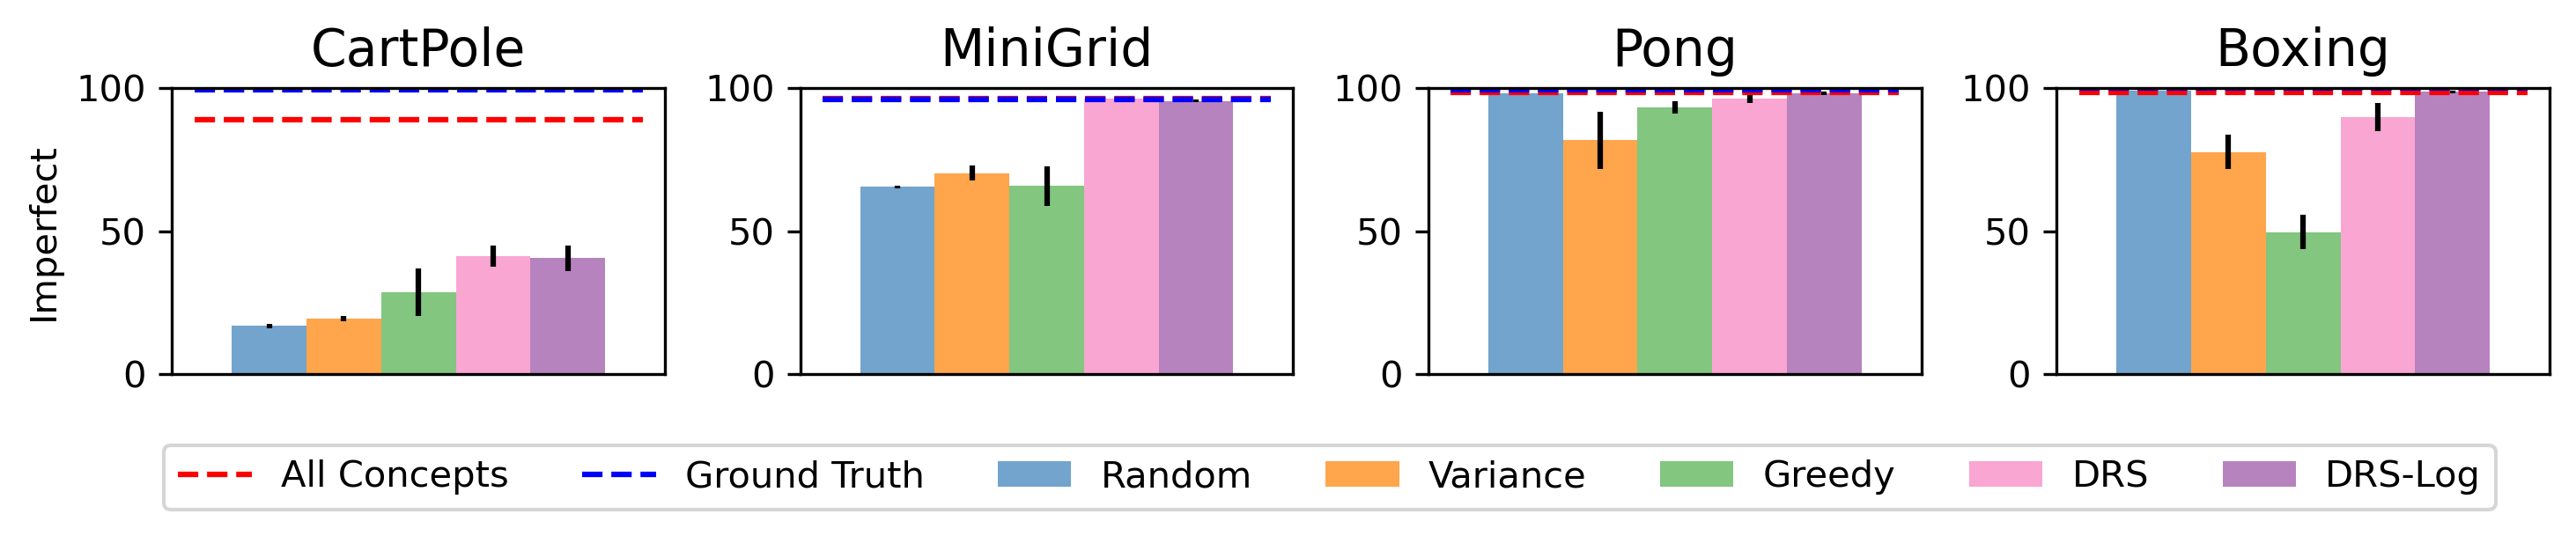

In [25]:
# Imperfect setting plot
plot_dimensions = (1, len(imperfect_environments))
titles   = [[name_to_nice[i] for i in imperfect_environments]]
y_labels = [["" for _ in range(len(imperfect_environments))]]
y_labels[0][0] = "Imperfect"
overall_format = {
    'figsize': (10, 2), 'style_size': style_size, 'has_grid': False,
    'y_lim':   [[[0, 100] for _ in range(4)]],
    'x_ticks': [[[[],[]] for _ in range(5)]],
}
fig, ax = create_axes(plot_dimensions, overall_format, titles=titles, y_labels=y_labels)
plt.tight_layout()

for i in range(len(imperfect_environments)):
    y_vals = all_performances_imperfect[i][1:]
    y_std  = all_performances_imperfect_std[i][1:]
    plot_bar(ax[0][i], list(range(len(y_vals))), y_vals, y_std, methods_dict, bar_format)
    ax[0][i].hlines(all_performances_imperfect[i][0], -0.25, 1.25,
                    label="All Concepts", color="red", linestyle="--")
    ax[0][i].hlines(all_baselines[i], -0.25, 1.25,
                    label="Ground Truth", color="blue", linestyle="--")
    
legend_format = {
    'style_size': style_size, 'type': 'is_global', 'loc': 'lower left',
    'ncol': 7, 'bbox_to_anchor': (0.075, -0.1), 'fontsize': 10,
}
create_legend(fig, ax, plot_dimensions, legend_format)
fig.savefig("figures/basic_comparison_methods_imperfect.pdf", dpi=300, bbox_inches='tight')

In [26]:
# ── Concept inspection (MiniGrid) ─────────────────────────────────────────────
names = get_all_mini_grid_names()
for m in ['drs', 'greedy', 'variance']:
    matching_params = get_results_matching_parameters(
        "basic", "",
        {'environment_string': 'mini_grid', 'training_timesteps': training_times['mini_grid'],
         'num_concepts_selected': num_concepts_per_env['mini_grid'],
         'setting':'perfect',
         'method': m, 'gold_timesteps': gold_timesteps['mini_grid']})
    print(f"\n{m}:")
    for res in matching_params:
        print("  ", [names[i] for i in res[m]['concepts']])


drs:
   ['X Pos_1', 'Y Pos_1', 'Y Pos_2', 'Dir_1', 'Dir_2', 'Dir_3', 'Key X_1', 'Door Y_1', 'Door Open_0', 'Left_0', 'Up_0']
   ['X Pos_3', 'Y Pos_3', 'Dir_1', 'Dir_2', 'Dir_3', 'Key Y_1', 'Key Y_3', 'Door Y_2', 'Right_0', 'Left_1', 'Up_1']
   ['X Pos_3', 'Y Pos_1', 'Dir_1', 'Dir_2', 'Dir_3', 'Key Y_1', 'Key Y_2', 'Key Y_3', 'Door Y_2', 'Right_1', 'Left_1']
   ['X Pos_1', 'Y Pos_1', 'Y Pos_2', 'Dir_1', 'Dir_2', 'Dir_3', 'Key X_1', 'Door Y_1', 'Door Open_0', 'Left_0', 'Up_1']
   ['X Pos_1', 'Y Pos_1', 'Y Pos_2', 'Dir_1', 'Dir_2', 'Dir_3', 'Key X_1', 'Door Y_1', 'Door Open_0', 'Left_0', 'Up_0']
   ['X Pos_1', 'Y Pos_1', 'Y Pos_2', 'Dir_1', 'Dir_2', 'Dir_3', 'Key X_1', 'Door Y_2', 'Door Open_0', 'Left_1', 'Up_1']
   ['X Pos_1', 'Y Pos_1', 'Y Pos_3', 'Dir_1', 'Dir_2', 'Dir_3', 'Key Y_1', 'Key Y_2', 'Door Y_2', 'Door Open_0', 'Left_0']
   ['X Pos_3', 'Y Pos_3', 'Dir_1', 'Dir_2', 'Dir_3', 'Key Y_1', 'Key Y_3', 'Door Y_2', 'Door Open_0', 'Left_0', 'Up_0']
   ['X Pos_1', 'Y Pos_1', 'Y Pos_2',

In [27]:
# ── In-text stats ─────────────────────────────────────────────────────────────
print("\nPerfect CartPole DRS / Random:", all_performances_perfect[0][-1] / all_performances_perfect[0][1])
print("Perfect MiniGrid DRS / Greedy:", all_performances_perfect[1][-1] / all_performances_perfect[1][2])
print("Perfect Boxing DRS / best baseline:", all_performances_perfect[-2][-1] / all_performances_perfect[-2][3])
print("Perfect Glucose DRS / best baseline:", all_performances_perfect[-1][-1] / all_performances_perfect[-1][-2])
print("Imperfect CartPole DRS / best baseline:", all_performances_imperfect[0][-1] / all_performances_imperfect[0][3])
print("Imperfect MiniGrid DRS-log / best baseline:", all_performances_imperfect[1][-2] / np.max(all_performances_imperfect[1][1:-2]))
print("Overlap DRS vs DRS-log in imperfect:")
for j, e in enumerate(imperfect_environments):
    ours = []
    for m in ['drs', 'drs_log']:
        mp = get_results_matching_parameters(
            "basic", "",
            {'environment_string': e, 'training_timesteps': training_times[e],
             'num_concepts_selected': num_concepts_per_env[e],
             'setting':'imperfect',
             'method': m, 'gold_timesteps': gold_timesteps[e]})
        ours.append([i[m]['concepts'] for i in mp])
    avg = [len(set(a).intersection(set(b))) / len(b)
           for a in ours[0] for b in ours[1]]
    print(f"  {e}: {np.mean(avg):.3f}")


Perfect CartPole DRS / Random: 2.198211300069383
Perfect MiniGrid DRS / Greedy: 1.2779547459741418
Perfect Boxing DRS / best baseline: 1.0440549582081582
Perfect Glucose DRS / best baseline: 1.3257555248074806
Imperfect CartPole DRS / best baseline: 1.417852561739865
Imperfect MiniGrid DRS-log / best baseline: 1.3701293907039367
Overlap DRS vs DRS-log in imperfect:
  cart_pole: 0.709
  mini_grid: 0.662
  pong: 0.517
  boxing: 0.482


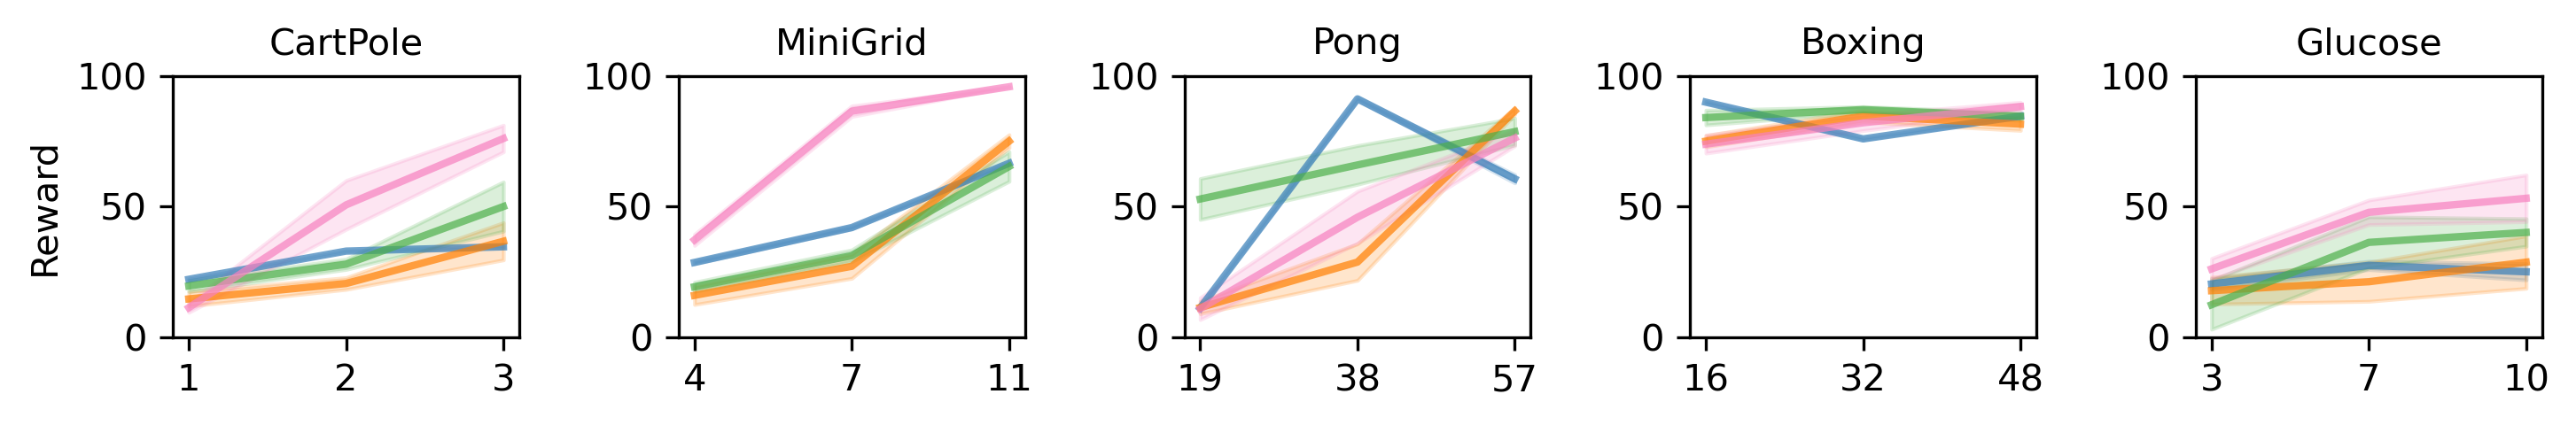

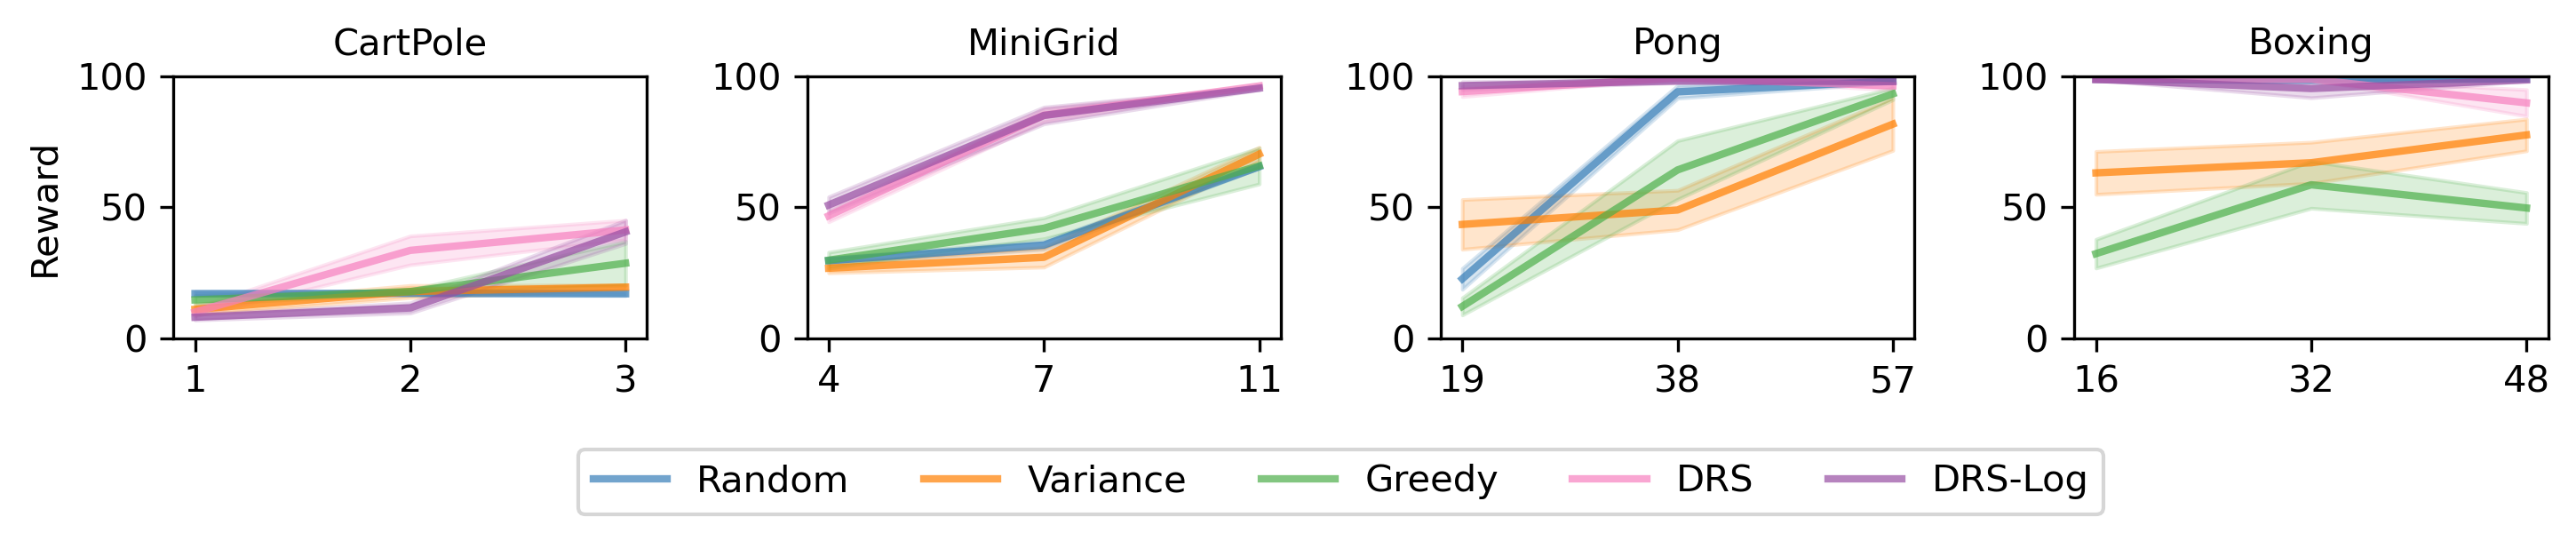

In [31]:
# ── Appendix E: Varied k ──────────────────────────────────────────────────────
for setting, envs, methods, exp_key in [
    ('perfect',  perfect_environments,  ["random", "variance", "greedy", "drs"],            'perfect'),
    ('imperfect', imperfect_environments, ["random", "variance", "greedy", "drs", "drs_log"], 'imperfect'),
]:
    all_performances_k     = []
    all_performances_k_std = []

    for j, e in enumerate(envs):
        temp_env, temp_env_std = [], []
        for m in methods:
            temp, temp_std = [], []
            for fraction in [0.33, 0.66, 1]:
                k = round(num_concepts_per_env[e] * fraction)
                mp = get_results_matching_parameters(
                    "imperfect", "",
                    {'environment_string': e, 'training_timesteps': training_times[e],
                     'num_concepts_selected': k, 'method': m,
                     'gold_timesteps': gold_timesteps[e], 'setting':exp_key})
                if len(mp) == 0:
                    mp = get_results_matching_parameters(
                        "basic", "",
                        {'environment_string': e, 'training_timesteps': training_times[e],
                         'num_concepts_selected': k, 'method': m,
                         'gold_timesteps': gold_timesteps[e], 'setting':exp_key})
                vals = [i[m]['reward'] for i in mp if m in i and not np.isnan(i[m]['reward'])]
                perf = method_scales[j](np.mean(vals)) if vals else 0
                temp.append(perf)
                temp_std.append(method_scales_std[j](np.std(vals)) / len(vals) ** 0.5 if vals else 0)
            temp_env.append(temp)
            temp_env_std.append(temp_std)
        all_performances_k.append(temp_env)
        all_performances_k_std.append(temp_env_std)

    plot_dimensions = (1, len(envs))
    titles   = [[name_to_nice[i] for i in envs]]
    y_labels = [["" for _ in range(len(envs))]]
    y_labels[0][0] = "Reward"

    x_tick_vals = [
        [[0, 1, 2], [round(num_concepts_per_env[envs[i]] * f) for f in [0.33, 0.66, 1]]]
        for i in range(len(envs))
    ]
    overall_format = {
        'figsize': (10, 2), 'style_size': style_size, 'has_grid': False,
        'y_lim':   [[[0, 100] for _ in range(len(envs))]],
        'x_ticks': [[x_tick_vals[i] for i in range(len(envs))]],
        'label_size': 10, 'title_size': 10,
    }
    fig, ax = create_axes(plot_dimensions, overall_format, titles=titles, y_labels=y_labels)
    line_format = {'color_palette': 'six_color', 'linewidth': 2}
    plt.tight_layout()

    for i in range(len(envs)):
        plot_line(ax[0][i],
                  [list(range(3)) for _ in methods],
                  all_performances_k[i],
                  all_performances_k_std[i],
                  [METHOD_DISPLAY[m] for m in methods],
                  line_format)

    if setting == 'imperfect':
        legend_format = {
            'style_size': style_size, 'type': 'is_global', 'loc': 'lower left',
            'ncol': 6, 'bbox_to_anchor': (0.23, -0.1), 'fontsize': 10,
        }
        create_legend(fig, ax, plot_dimensions, legend_format)

    fig.savefig(f"figures/{setting}_varied_k.pdf", dpi=300, bbox_inches='tight')

In [32]:
# ── Figure 3: Accuracy × num_concepts heatmap ────────────────────────────────
num_concepts_heatmap = [[1, 2, 3], [3, 6, 11], [57//4, 57//2, 57], [12, 24, 48], [2, 5, 10]]
accuracies = [0.75, 0.85, 0.95]
max_perf = [b + 0.001 for b in all_baselines]
max_perf[3] = 100
max_perf[2] = 21

In [33]:
heatmap_by_env = [
    [[0] * len(num_concepts_heatmap[i]) for _ in accuracies]
    for i in range(len(perfect_environments))
]

In [34]:
for i, e in enumerate(perfect_environments):
    for j, acc in enumerate(accuracies):
        for k_idx, n in enumerate(num_concepts_heatmap[i]):
            mp = get_results_matching_parameters(
                "imperfect", "",
                {'environment_string': e, 'concept_accuracy': acc,
                 'num_concepts_selected': n, 'training_timesteps': training_times[e]})
            print(e, acc, n, len(mp),
                  [m['drs_log']['reward'] for m in mp],
                  round(np.mean([m['drs_log']['reward'] for m in mp]) / max_perf[i], 2) * 100)
            if mp and 'drs_log' in mp[0]:
                heatmap_by_env[i][j][k_idx] = round(
                    method_scales[i](np.mean([m['drs_log']['reward'] for m in mp])))

cart_pole 0.75 1 6 [28.070244450688396, 27.75, 60.42050970873787, 62.542319749216304, 35.57463484146776, 28.066610455311974] 41.0
cart_pole 0.75 2 6 [81.25693311582381, 83.25836120401338, 82.13613861386139, 36.20653357531761, 36.071919045898085, 59.69106178764247] 64.0
cart_pole 0.75 3 6 [99.50250250250251, 97.3330068560235, 97.74827925270404, 98.10453648915187, 99.11044776119402, 97.549115913556] 99.0
cart_pole 0.85 1 6 [28.510711225364183, 28.07564679415073, 38.16934250764526, 82.87209302325581, 83.964586846543, 38.262169413568415] 50.0
cart_pole 0.85 2 6 [198.11244979919678, 39.12828560219694, 203.66324435318276, 81.11635475996745, 78.15058823529412, 38.89676665368134] 107.0
cart_pole 0.85 3 6 [213.4021505376344, 211.7008547008547, 209.30655391120507, 208.25105485232066, 220.6, 221.87892376681614] 216.0
cart_pole 0.95 1 6 [39.188701451549626, 39.556435643564356, 39.373669688608594, 102.40020576131687, 29.155036496350366, 39.14207221350078] 49.0
cart_pole 0.95 2 6 [39.458711971552745

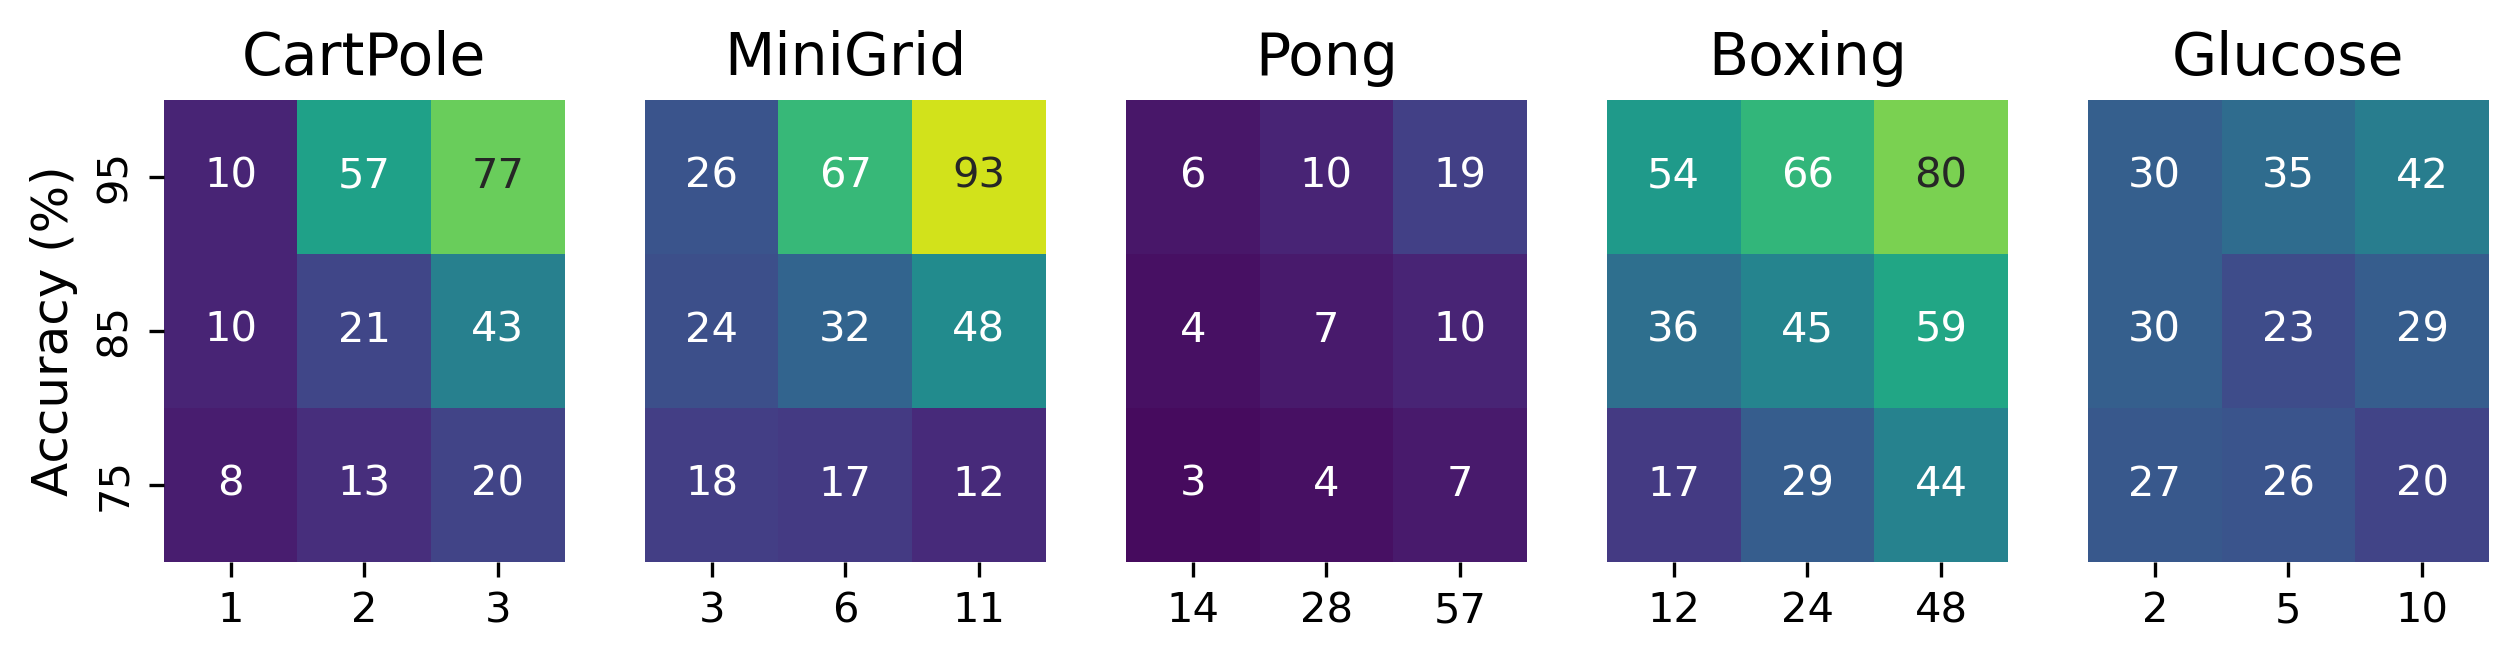

In [35]:
import matplotlib as mpl
fig, ax = create_axes(
    (1, len(perfect_environments)),
    {'figsize': (10, 2), 'style_size': style_size, 'has_grid': False},
    titles=[[name_to_nice[i] for i in perfect_environments]])
for i in range(len(perfect_environments)):
    sns.heatmap(
        heatmap_by_env[i], ax=ax[0][i], cmap="viridis",
        xticklabels=num_concepts_heatmap[i],
        yticklabels=["75", "85", "95"] if i == 0 else [],
        vmin=0, vmax=100, cbar=False, annot=True)
    ax[0][i].invert_yaxis()
ax[0][0].set_ylabel("Accuracy (%)", fontsize=12)
fig.savefig("figures/num_concepts_accuracy.pdf", dpi=300, bbox_inches='tight')

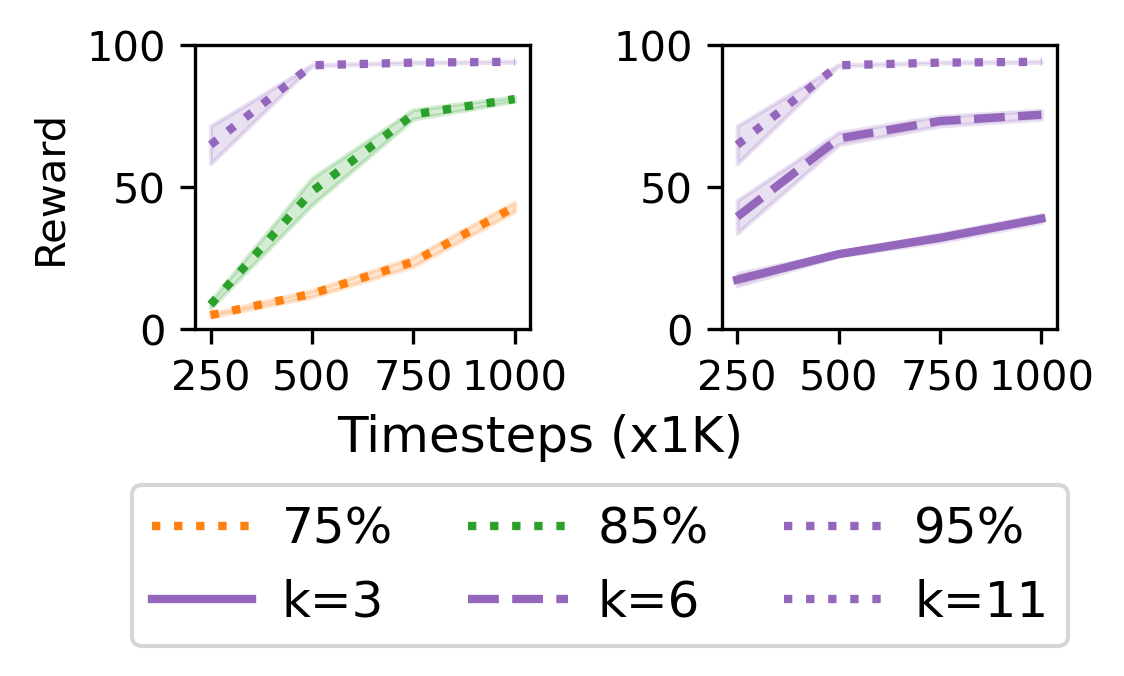

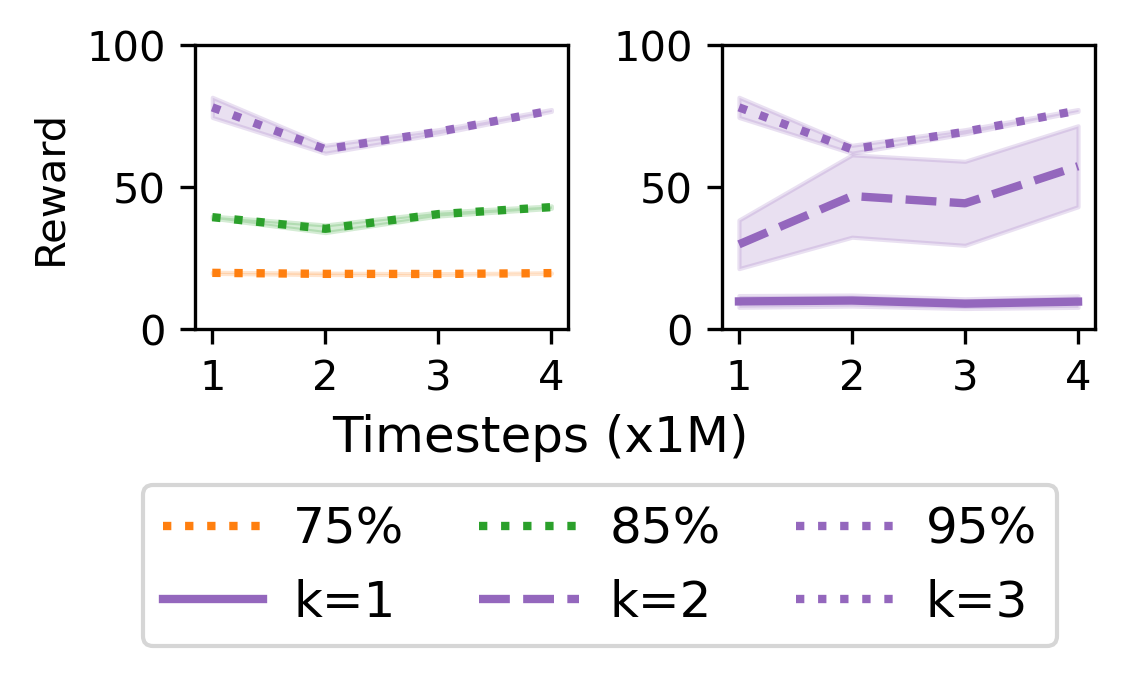

In [36]:
# ── Figure 5 + CartPole variant: Training curves (accuracy × k) ───────────────
for env, ts_values, k_values, scale_idx in [
    ("mini_grid", [250000, 500000, 750000, 1000000], [3, 6, 11],  1),
    ("cart_pole", [1000000, 2000000, 3000000, 4000000], [1, 2, 3], 0),
]:
    if env == "mini_grid":
        x_tick_labels = [str(t // 1000) for t in ts_values]
    else:
        x_tick_labels = [str(t // 1000000) for t in ts_values]

    rewards_accuracy, std_accuracy = [], []
    for acc in [0.75, 0.85, 0.95]:
        temp, temp_std = [], []
        for t in ts_values:
            mp = get_results_matching_parameters(
                "imperfect", "",
                {'environment_string': env, 'num_concepts_selected': k_values[-1],
                 'concept_accuracy': acc, 'training_timesteps': t})
            temp.append(method_scales[scale_idx](np.mean([i['drs_log']['reward'] for i in mp])))
            temp_std.append(method_scales_std[scale_idx](
                np.std([i['drs_log']['reward'] for i in mp])) / len(mp) ** 0.5)
        rewards_accuracy.append(temp)
        std_accuracy.append(temp_std)

    rewards_k, std_k = [], []
    for n in k_values:
        temp, temp_std = [], []
        for t in ts_values:
            mp = get_results_matching_parameters(
                "imperfect", "",
                {'environment_string': env, 'num_concepts_selected': n,
                 'concept_accuracy': 0.95, 'training_timesteps': t})
            temp.append(method_scales[scale_idx](np.mean([i['drs_log']['reward'] for i in mp])))
            temp_std.append(method_scales_std[scale_idx](
                np.std([i['drs_log']['reward'] for i in mp])) / len(mp) ** 0.5)
        rewards_k.append(temp)
        std_k.append(temp_std)

    overall_format = {
        'figsize': (4, 2), 'style_size': style_size, 'has_grid': False,
        'x_ticks': [[[[0, 1, 2, 3], x_tick_labels] for _ in range(2)]],
        'y_ticks': [[[[0, 50, 100], ["0", "50", "100"]] for _ in range(2)]],
        'y_lim':   [[[0, 100] for _ in range(2)]],
    }
    fig, ax = create_axes(
        (1, 2), overall_format,
        y_labels=[["Reward", ""]], x_labels=[["", ""]])
    
    if env == "mini_grid":
        fig.supxlabel("Timesteps (x1K)", y=0.13)
    else:
        fig.supxlabel("Timesteps (x1M)", y=0.13)
    plt.tight_layout()

    accuracy_labels = ["75%", "85%", "95%"]
    k_labels = [f"k={n}" for n in k_values]
    x_groups = [list(range(len(ts_values))) for _ in range(3)]

    plot_line(ax[0][0], x_groups, rewards_accuracy, std_accuracy,
              accuracy_labels, {'color_palette': 'three_color_primary', 'linewidth': 2, 'linestyle': ':'})
    plot_line(ax[0][1], x_groups, rewards_k, std_k,
              k_labels, {'color_palette': "#9467bd", 'linewidth': 2, 'linestyle': ['-', '--', ':']})

    handles_l, labels_l = ax[0][0].get_legend_handles_labels()
    handles_r, labels_r = ax[0][1].get_legend_handles_labels()
    fig.legend(
        [handles_l[0], handles_r[0], handles_l[1], handles_r[1], handles_l[2], handles_r[2]],
        [labels_l[0],  labels_r[0],  labels_l[1],  labels_r[1],  labels_l[2],  labels_r[2]],
        loc="lower center", ncol=3, fontsize=12, frameon=True,
        columnspacing=1.5, handletextpad=0.6, bbox_to_anchor=(0.55, -0.22))
    plt.tight_layout()
    fig.subplots_adjust(bottom=0.35)

    suffix = "cart_pole" if env == "cart_pole" else ""
    fname  = f"accuracy_num_concepts{'_' + suffix if suffix else ''}.pdf"
    fig.savefig(f"figures/{fname}", dpi=300, bbox_inches='tight')

In [37]:
# ── Figure 4 + Appendix G: Intervention ───────────────────────────────────────
intervention_probability = [0.25, 0.5, 0.75]
e = "cart_pole"

In [38]:
cart_pole_interventions     = [all_performances_imperfect[0][1:]]
cart_pole_interventions_std = [all_performances_imperfect_std[0][1:]]

In [39]:
for prob in intervention_probability:
    temp, temp_std = [], []
    for m in imperfect_methods[1:]:   # skip all_concepts
        mp = get_results_matching_parameters(
            "intervention", "",
            {'environment_string': e, 'training_timesteps': training_times[e],
             'num_concepts_selected': num_concepts_per_env[e],
             'method': m, 'intervention_prob': prob})
        print(prob, m, len(mp), [i['parameters']['seed'] for i in mp])
        if mp:
            temp.append(method_scales[0](np.mean([i[m]['reward'] for i in mp])))
            temp_std.append(method_scales[0](np.mean([i[m]['reward'] for i in mp])) / len(mp) ** 0.5)
        else:
            temp.append(0.0001)
            temp_std.append(0)
    cart_pole_interventions.append(temp)
    cart_pole_interventions_std.append(temp_std)

0.25 random 6 [43, 46, 44, 47, 42, 45]
0.25 variance 6 [45, 46, 44, 43, 47, 42]
0.25 greedy 6 [43, 44, 45, 47, 42, 46]
0.25 drs 12 [44, 45, 44, 46, 42, 43, 43, 42, 43, 42, 47, 44]
0.25 drs_log 9 [45, 42, 44, 43, 43, 42, 47, 46, 44]
0.5 random 6 [45, 46, 47, 44, 42, 43]
0.5 variance 6 [44, 43, 45, 47, 46, 42]
0.5 greedy 6 [45, 42, 43, 46, 47, 44]
0.5 drs 15 [43, 43, 43, 45, 44, 46, 42, 44, 44, 46, 45, 47, 42, 42, 47]
0.5 drs_log 9 [42, 43, 46, 44, 44, 43, 47, 42, 45]
0.75 random 5 [45, 46, 43, 47, 42]
0.75 variance 5 [47, 45, 46, 43, 42]
0.75 greedy 4 [45, 46, 42, 47]
0.75 drs 9 [43, 42, 45, 44, 46, 44, 42, 43, 47]
0.75 drs_log 9 [44, 44, 42, 42, 47, 43, 46, 43, 45]


In [40]:
cart_pole_interventions.append(all_performances_perfect[0][1:] + all_performances_perfect[0][-1:])
cart_pole_interventions_std.append(all_performances_perfect_std[0][1:] + all_performances_perfect_std[0][-1:])
intervention_probability_plot = [0.0] + intervention_probability + [1.0]

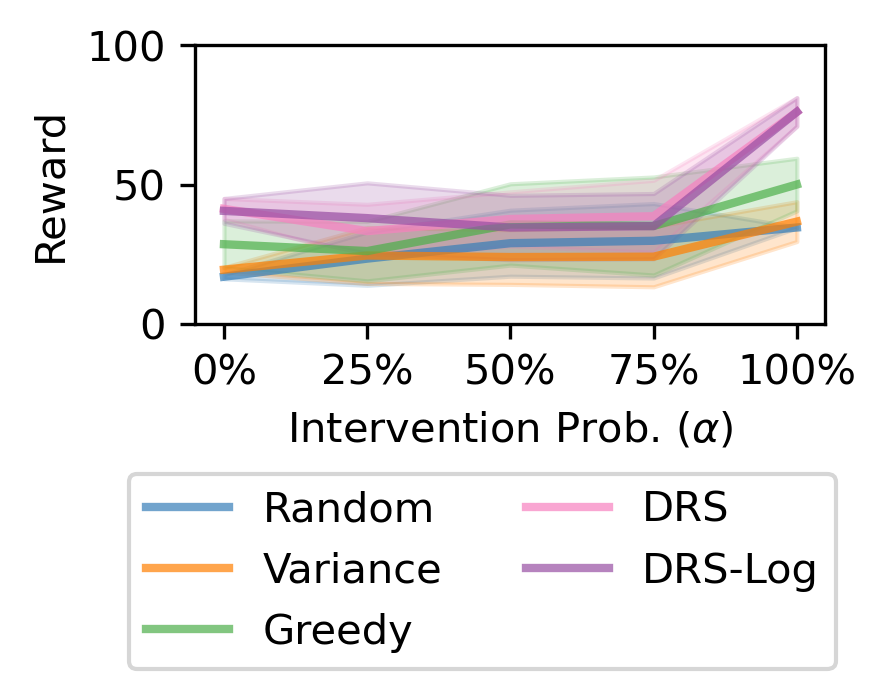

In [42]:
# Appendix G plot
overall_format = {
    'figsize': (3.3, 2), 'style_size': style_size, 'has_grid': False,
    'x_ticks': [[[list(range(len(intervention_probability_plot))),
                  ["0%", "25%", "50%", "75%", "100%"]] for _ in range(5)]],
    'y_lim': [[[0, 100]]],
}
fig, ax = create_axes(
    (1, 1), overall_format,
    titles=[[""]], x_labels=[["Intervention Prob. ($\\alpha$)"]], y_labels=[["Reward"]])
line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()
x_groups = [list(range(len(intervention_probability_plot))) for _ in imperfect_methods[1:]]
plot_line(ax[0][0], x_groups,
          np.array(cart_pole_interventions).T,
          np.array(cart_pole_interventions_std).T,
          ['Random', 'Variance', 'Greedy', 'DRS', 'DRS-Log'], line_format)
legend_format = {
    'style_size': style_size, 'type': 'is_global', 'loc': 'lower left',
    'ncol': 2, 'bbox_to_anchor': (0.17, -0.25), 'fontsize': 10,
}
create_legend(fig, ax, (1, 1), legend_format)
fig.savefig("figures/intervention_percent.pdf", dpi=300, bbox_inches='tight')

In [43]:
b = get_results_matching_parameters(
            "intervention", "",
            dict(environment_string='cart_pole', training_timesteps=4_000_000,
                 num_concepts_selected=num_concepts_per_env['cart_pole'],
                 method='drs', intervention_prob=0.5))

In [52]:
# Figure 4: Accuracy–reward tradeoff across environments
ENV_INTERVENTION_CONFIG = {
    "cart_pole": dict(timesteps=4_000_000, scale_idx=0),
    "mini_grid": dict(timesteps=250_000,   scale_idx=1),
    "pong":      dict(timesteps=4_000_000, scale_idx=2),
    "boxing":    dict(timesteps=2_000_000, scale_idx=3),
}
intervention_methods = ["random", "variance", "greedy", "drs", "drs_log"]
def get_intervention_performance(env, prob):
    cfg = ENV_INTERVENTION_CONFIG[env]
    out = []
    for m in intervention_methods:
        mp = get_results_matching_parameters(
            "intervention", "",
            dict(environment_string=env,
                 training_timesteps=cfg["timesteps"],
                 num_concepts_selected=num_concepts_per_env[env],
                 method=m, intervention_prob=prob))
        print(m, env, len(mp), [(i[m]["reward"], i['parameters']['seed']) for i in mp])
        out.append(method_scales[cfg["scale_idx"]](np.mean([i[m]["reward"] for i in mp]))
                   if mp else 1e-4)
    return out
intervention_results = {}
for env in ENV_INTERVENTION_CONFIG:
    cfg   = ENV_INTERVENTION_CONFIG[env]
    sidx  = cfg["scale_idx"]

    if env == "cart_pole":
        baseline_rewards     = all_performances_imperfect[sidx][1:]
    else:
        baseline_rewards     = get_intervention_performance(env, 0.0)
    intervention_rewards = get_intervention_performance(env, 0.5)

    mp = get_results_matching_parameters(
        "intervention", "",
        dict(environment_string=env, training_timesteps=cfg["timesteps"],
             num_concepts_selected=num_concepts_per_env[env],
             method="drs_log", intervention_prob=0.5))
    accuracies = np.array(mp[0]["concept_accuracy"])
    print(env, accuracies.tolist())

    selected = []
    for m in intervention_methods:
        p = get_results_matching_parameters(
            "intervention", "",
            dict(environment_string=env, training_timesteps=cfg["timesteps"],
                 num_concepts_selected=num_concepts_per_env[env],
                 method=m, intervention_prob=0.5))
        selected.append([i[m]["concepts"] for i in p])

    baseline_acc = np.array([np.mean([np.mean(accuracies[j]) for j in i]) for i in selected])
    intervention_acc = np.array([
        np.mean([np.mean(0.5 * np.ones(len(k)) + 0.5 * accuracies[k]) for k in i])
        for i in selected])

    intervention_results[env] = (
        np.column_stack([baseline_acc,     baseline_rewards]),
        np.column_stack([intervention_acc, intervention_rewards]),
    )

random cart_pole 6 [(138.952580195258, 45), (163.3014827018122, 46), (177.7168458781362, 47), (123.38881987577639, 44), (134.13765182186233, 42), (132.57066666666665, 43)]
variance cart_pole 6 [(116.94705882352942, 44), (82.72885572139303, 43), (84.6358234295416, 45), (97.92527040314651, 47), (157.08399366085578, 46), (181.5, 42)]
greedy cart_pole 6 [(252.04580152671755, 45), (181.5, 42), (158.2531847133758, 43), (160.33333333333334, 46), (109.54615384615384, 47), (210.26652452025587, 44)]
drs cart_pole 6 [(252.73145780051152, 43), (258.0286458333333, 45), (156.38522012578616, 44), (188.72053231939162, 46), (183.5037037037037, 42), (465.91037735849056, 47)]
drs_log cart_pole 6 [(183.5037037037037, 42), (185.8314606741573, 43), (150.70257966616086, 46), (100.97061803444782, 44), (109.61936193619361, 47), (258.0286458333333, 45)]
cart_pole [0.9773078046135235, 0.9734284403287031, 0.8698535852834439, 0.8680181871271847, 0.8628457014140909, 0.8645559587869687, 0.9717181829558253, 0.9716764

drs_log pong 6 [(-11.666666666666666, 45), (4.458333333333333, 44), (-17.666666666666668, 46), (-1.8125, 42), (-15.24, 47), (-10.23076923076923, 43)]
pong [1.0, 1.0, 1.0, 0.6852296807995862, 0.6589244297608917, 1.0, 0.639735696050458, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.6852296807995862, 0.6589244297608917, 1.0, 0.639735696050458, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.6834609801271462, 0.6571724149438521, 1.0, 0.6377333934024128, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.6834609801271462, 0.6571724149438521, 1.0, 0.6377333934024128, 1.0, 0.99734694899134, 0.9987402179172715, 1.0, 1.0, 1.0, 0.7647544676377834, 0.7647544676377834, 0.6834609801271462, 0.6571724149438521, 0.9366438070447681, 0.6377333934024128, 1.0, 0.9845155261884501, 0.980619378952462, 0.9652266773456141, 1.0, 1.0, 0.7080642739150023, 0.7647544676377834, 0.6809581018170896, 0.6559877192104253, 0.9366438070447681, 0.6305334467971501, 1.0, 0.9636331781548781, 0.9515776476281057, 0.8272429961121956, 1.0, 0.8579783

In [53]:
def plot_intervention_env(ax, baseline, intervention, title, xlim, ylim):
    markers = ['o', 's', '^', 'v', 'D']
    for i, (x, y) in enumerate(intervention):
        ax.scatter(x, y, marker=markers[i], s=70, color='C0', alpha=0.7)
    for i, (x, y) in enumerate(baseline):
        ax.scatter(x, y, marker=markers[i], s=70, color='C1', alpha=0.7)
    for b, iv in zip(baseline, intervention):
        ax.annotate("", xy=iv, xytext=b,
                    arrowprops=dict(arrowstyle="->", ls="--", lw=1, alpha=0.5))
    ax.set_title(title); ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xlabel("Accuracy")
    if title == "Cart Pole":
        ax.set_ylabel("Reward")
    ax.grid(alpha=0.25)

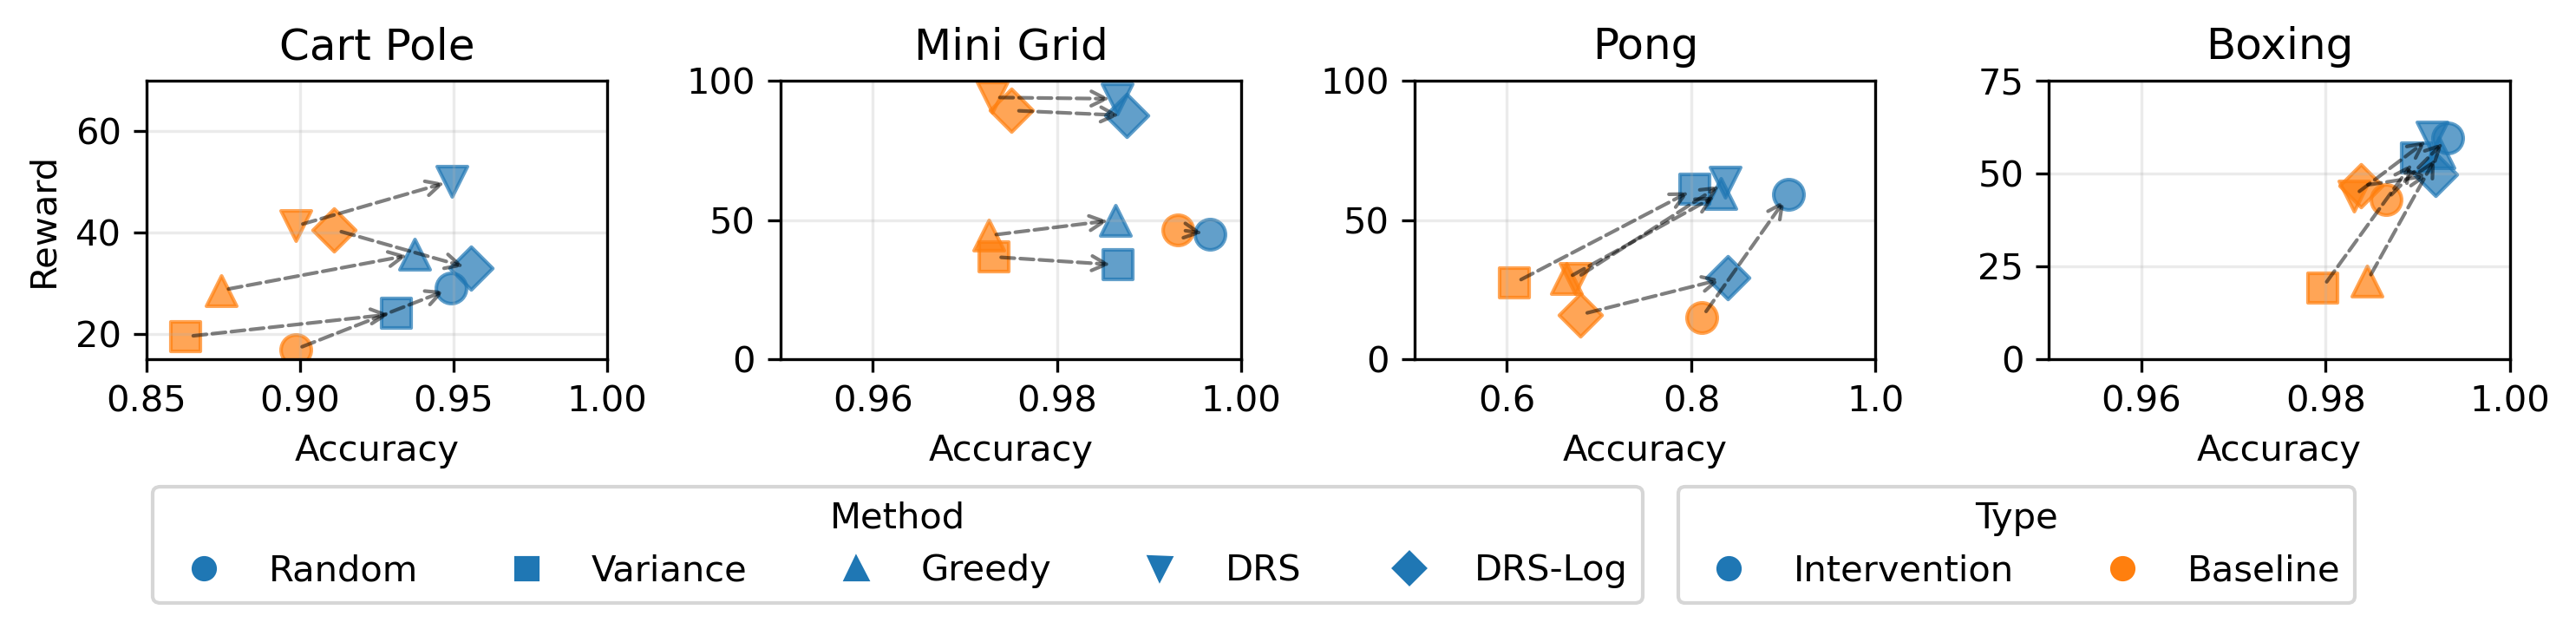

In [55]:
PLOT_CONFIG = {
    "cart_pole": ([0.85, 1.0], [15, 70]),
    "mini_grid": ([0.95, 1.0], [0, 100]),
    "pong":      ([0.5,  1.0], [0, 100]),
    "boxing":    ([0.95, 1.0], [0, 75]),
}
fig, axes = plt.subplots(1, 4, figsize=(10, 2))
for ax_i, env in zip(axes, ["cart_pole", "mini_grid", "pong", "boxing"]):
    baseline, intervention = intervention_results[env]
    plot_intervention_env(ax_i, baseline, intervention,
                          env.replace("_", " ").title(), *PLOT_CONFIG[env])
color_handles = [
    mlines.Line2D([], [], color='C0', marker='o', linestyle='None', label='Intervention'),
    mlines.Line2D([], [], color='C1', marker='o', linestyle='None', label='Baseline'),
]
method_handles = [
    mlines.Line2D([], [], color='C0', marker=m, linestyle='None',
                  label=METHOD_DISPLAY[k])
    for m, k in zip(['o', 's', '^', 'v', 'D'], intervention_methods)
]
fig.legend(handles=color_handles,  loc="upper center", ncol=2, title="Type",   bbox_to_anchor=(0.78, 0.075))
fig.legend(handles=method_handles, loc="upper center", ncol=5, title="Method", bbox_to_anchor=(0.35, 0.075))
plt.tight_layout()
fig.savefig("figures/intervention_comparison.pdf", dpi=300, bbox_inches='tight')

In [56]:
# ── Appendix I: Varied gold timesteps ────────────────────────────────────────
gold_ts_values = [100000, 250000, 500000]
ablation_methods = ["variance", "greedy", "drs", "drs_log"]
e = "mini_grid"

In [57]:
performance_by_gold, gold_std = [], []
for m in ablation_methods:
    temp, temp_std = [], []
    for g in gold_ts_values:
        mp = get_results_matching_parameters(
            "ablations", "",
            {'environment_string': e, 'gold_timesteps': g,
             'method': m, 'training_timesteps': 500_000})
        val = method_scales[1](np.mean([i[m]['reward'] for i in mp])) if mp else 0
        print(m, g, len(mp))
        temp.append(val)
        temp_std.append(method_scales_std[1](np.std([i[m]['reward'] for i in mp])) / len(mp) ** 0.5
                        if mp else 0)
    performance_by_gold.append(temp)
    gold_std.append(temp_std)

variance 100000 6
variance 250000 6
variance 500000 6
greedy 100000 6
greedy 250000 6
greedy 500000 6
drs 100000 12
drs 250000 12
drs 500000 12
drs_log 100000 6
drs_log 250000 6
drs_log 500000 6


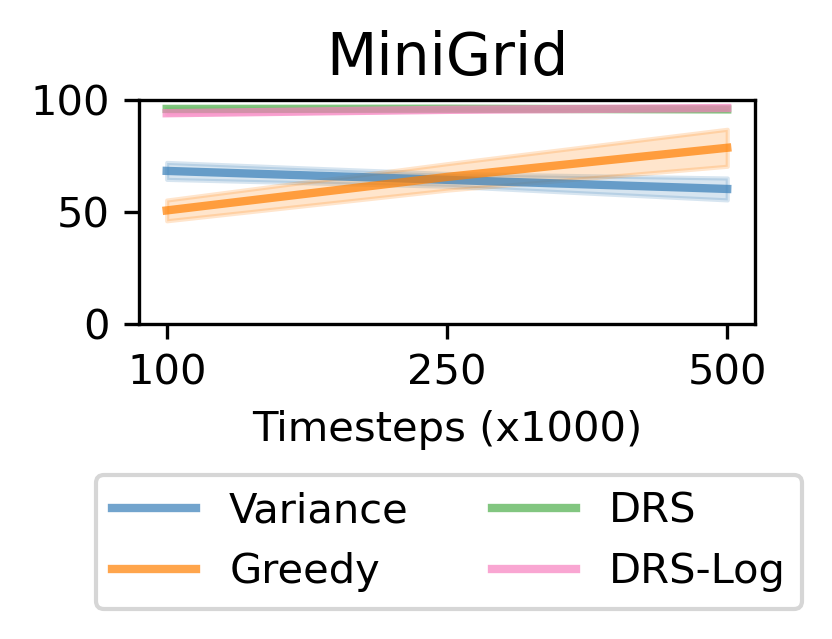

In [59]:
overall_format = {
    'figsize': (3, 2), 'style_size': style_size, 'has_grid': False,
    'x_ticks': [[[list(range(len(gold_ts_values))),
                  [str(g // 1000) for g in gold_ts_values]] for _ in range(5)]],
    'y_lim': [[[0, 100]]],
}
fig, ax = create_axes((1, 1), overall_format,
                      titles=[["MiniGrid"]], x_labels=[["Timesteps (x1000)"]])
line_format = {'color_palette': 'six_color', 'linewidth': 2}
plt.tight_layout()
plot_line(ax[0][0], [list(range(3)) for _ in ablation_methods],
          performance_by_gold, gold_std,
          [METHOD_DISPLAY[m] for m in ablation_methods], line_format)
legend_format = {
    'style_size': style_size, 'type': 'is_global', 'loc': 'lower left',
    'ncol': 2, 'bbox_to_anchor': (0.15, -0.15), 'fontsize': 10,
}
create_legend(fig, ax, (1, 1), legend_format)
fig.savefig("figures/gold_timesteps.pdf", dpi=300, bbox_inches='tight')

In [60]:
# ── Appendix D: Rho / P1c ablation ───────────────────────────────────────────
ablation_rho_methods = ["drs_no_relax", "drs_rho_0", "drs_rho_05", "drs", "drs_rho_099"]
rho_label_map = {
    0: 'Non-Relax.',
    1: r'$\rho=0$',
    2: r'$\rho=0.5$',
    3: r'$\rho=0.75$ (DRS)',
    4: r'$\rho=0.99$',
}
rho_envs = ['cart_pole', 'mini_grid']

In [87]:
all_perf_perfect_lp,   all_std_perfect_lp   = [], []
all_perf_imperfect_lp, all_std_imperfect_lp = [], []
rho_baselines = []

In [88]:
for j, e in enumerate(rho_envs):
    for container, std_container, exp_key in [
        (all_perf_perfect_lp,   all_std_perfect_lp,   'perfect'),
        (all_perf_imperfect_lp, all_std_imperfect_lp, 'imperfect'),
    ]:
        temp, temp_std = [], []
        for m in ablation_rho_methods:
            mp = get_results_matching_parameters(
                "basic", "",
                {'environment_string': e, 'training_timesteps': training_times[e],
                 'num_concepts_selected': num_concepts_per_env[e],
                 'setting':exp_key, 'method': m,
                 'gold_timesteps': gold_timesteps[e]})
            print(exp_key, e, m, len(mp),
                  [(i[m]['reward'], i['parameters']['seed'], i[m]['concepts'])
                   for i in mp if m in i])
            vals = [i[m]['reward'] for i in mp if m in i and not np.isnan(i[m]['reward'])]
            temp.append(method_scales[j](np.mean(vals)) if vals else 0)
            temp_std.append(method_scales[j](np.std(vals) / len(vals) ** 0.5) if vals else 0)
        container.append(temp)
        std_container.append(temp_std)

    mp = get_results_matching_parameters(
        "basic", "",
        {'environment_string': e, 'training_timesteps': training_times[e],
         'gold_timesteps': gold_timesteps[e],
         'num_concepts_selected': num_concepts_per_env[e],
         'setting':'imperfect', 'method': 'ground_truth'})
    vals = [i['ground_truth']['reward'] for i in mp
            if 'ground_truth' in i and not np.isnan(i['ground_truth']['reward'])]
    rho_baselines.append(method_scales[j](np.mean(vals)) if vals else 0)
rho_baselines.append(0)

perfect cart_pole drs_no_relax 6 [(197.99600798403193, 46, [1, 4, 7]), (417.0425531914894, 47, [1, 7, 10]), (406.19166666666666, 45, [1, 7, 10]), (410.9916666666667, 43, [1, 7, 10]), (204.00821355236138, 42, [1, 4, 7]), (413.1386554621849, 44, [1, 7, 10])]
perfect cart_pole drs_rho_0 6 [(457.16355140186914, 47, [4, 7, 10]), (417.017094017094, 43, [3, 7, 10]), (454.78139534883724, 46, [4, 7, 10]), (457.3488372093023, 44, [4, 7, 10]), (455.2083333333333, 42, [4, 7, 10]), (448.3761467889908, 45, [4, 7, 10])]
perfect cart_pole drs_rho_05 6 [(457.3488372093023, 44, [4, 7, 10]), (417.017094017094, 43, [3, 7, 10]), (455.2083333333333, 42, [4, 7, 10]), (457.16355140186914, 47, [4, 7, 10]), (448.3761467889908, 45, [4, 7, 10]), (454.78139534883724, 46, [4, 7, 10])]
perfect cart_pole drs 15 [(204.00821355236138, 42, [1, 4, 7]), (294.46666666666664, 42, [5, 7, 9]), (406.19166666666666, 45, [1, 7, 10]), (413.1386554621849, 44, [1, 7, 10]), (198.51612903225808, 44, [0, 7, 9]), (417.017094017094, 43,

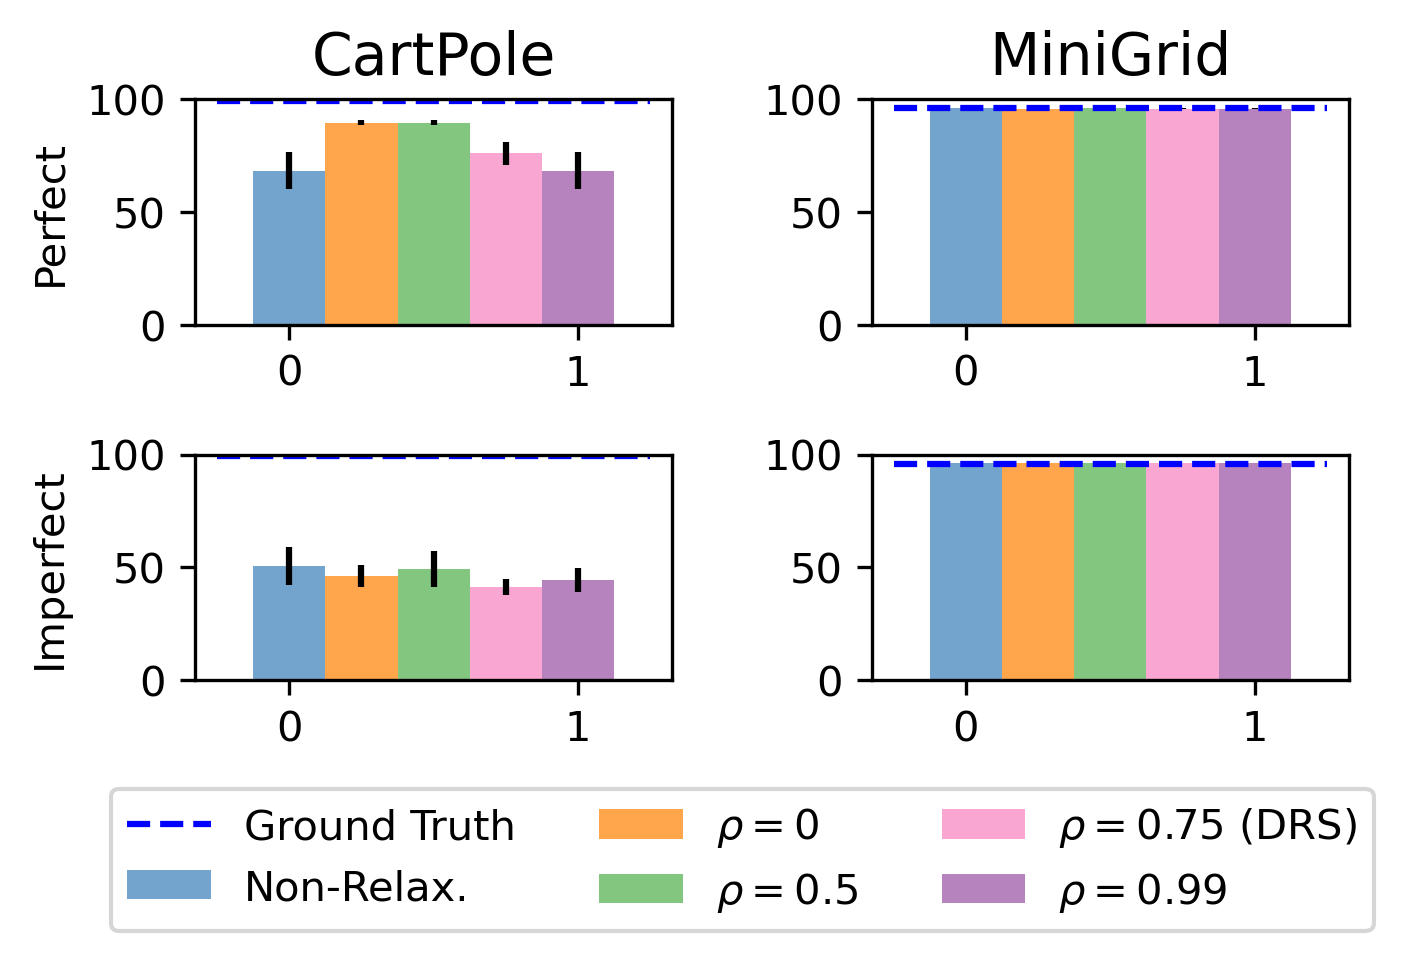

In [89]:
overall_format = {
    'figsize': (5, 3), 'style_size': style_size, 'has_grid': False,
    'y_lim': [[[0, 100] for _ in range(5)] for _ in range(2)],
}
fig, ax = create_axes(
    (2, len(rho_envs)), overall_format,
    titles=[[name_to_nice[e] for e in rho_envs], ["", ""]],
    y_labels=[["Perfect", ""], ["Imperfect", ""]])
bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size}
plt.tight_layout()
for i in range(len(rho_envs)):
    for row, (perf, std) in enumerate([
        (all_perf_perfect_lp[i],   all_std_perfect_lp[i]),
        (all_perf_imperfect_lp[i], all_std_imperfect_lp[i]),
    ]):
        plot_bar(ax[row][i], list(range(len(perf))), perf, std, rho_label_map, bar_format)
        ax[row][i].hlines(rho_baselines[i], -0.25, 1.25,
                          label="Ground Truth", color="blue", linestyle="--")
legend_format = {
    'style_size': style_size, 'type': 'is_global', 'loc': 'lower left',
    'ncol': 3, 'bbox_to_anchor': (0.1, -0.125), 'fontsize': 10,
}
create_legend(fig, ax, (2, len(rho_envs)), legend_format)
fig.savefig("figures/perfect_other_methods.pdf", dpi=300, bbox_inches='tight')

In [68]:
# ── Figure 6: CUB ─────────────────────────────────────────────────────────────
cub_params = get_results_matching_parameters("cub", "", {"num_concepts_selected": 311})
cub_params = [m for m in cub_params if "epochs" not in m["parameters"]]

In [69]:
C_VALUES    = list(range(20, 311, 20))
INTERVENTIONS = [0.2, 0.4, 0.6, 0.8, 1.0]
CUB_METHODS = {
    "random":   "Random",
    "variance": "Variance",
    "greedy":   "Greedy",
    "drs":      "DRS",
    "drs_log":  "DRS-Log",
}

In [70]:
def cub_mean_stderr(params, section, method, xs):
    vals = np.array([[p[section][method][str(x)]["reward"] for x in xs] for p in params])
    return vals.mean(axis=0), vals.std(axis=0) / np.sqrt(len(vals))

In [71]:
def cub_similarity(params, method, xs):
    vals = np.array([
        [len(set(p["imperfect"][method][str(x)]["concepts"])
             & set(p["imperfect"]["manual"]["concepts"])) / x
         for x in xs]
        for p in params])
    return vals.mean(axis=0), vals.std(axis=0) / np.sqrt(len(vals))

In [72]:
cub_params[0]['imperfect'].keys()

dict_keys(['manual', 'random', 'variance', 'greedy', 'drs', 'drs_log'])

In [73]:
cub_rewards, cub_rewards_se = {}, {}
cub_sim,     cub_sim_se     = {}, {}
for k in CUB_METHODS:
    cub_rewards[k], cub_rewards_se[k] = cub_mean_stderr(cub_params, "imperfect", k, C_VALUES)
    cub_sim[k],     cub_sim_se[k]     = cub_similarity(cub_params, k, C_VALUES)

In [74]:
manual_reward = np.mean([p["imperfect"]["manual"]["reward"] for p in cub_params])
print("Manual reward:", manual_reward)
print("DRS at k=112 vs manual:", cub_rewards["drs"][-1] / manual_reward)

Manual reward: 0.615493038775745
DRS at k=112 vs manual: 1.006262560171987


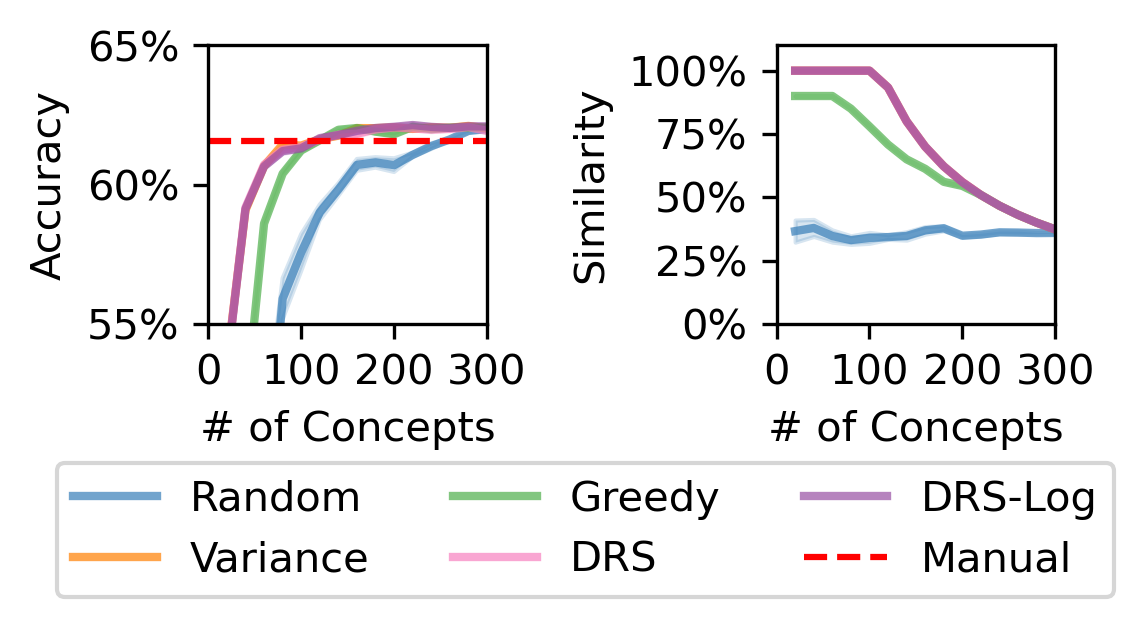

In [75]:
overall_format = {
    'figsize': (4, 2), 'style_size': style_size, 'has_grid': False,
    'x_lim':   [[[20, 300], [20, 300]]],
    'y_lim':   [[[0.55, 0.65], [0, 1.1]]],
    'y_ticks': [[[[0.55, 0.6, 0.65], ["55%", "60%", "65%"]],
                  [[0, 0.25, 0.5, 0.75, 1], ["0%", "25%", "50%", "75%", "100%"]]]],
    'x_ticks': [[[[0, 100, 200, 300]] * 2, [[0, 100, 200, 300]] * 2]],
    'label_size': 10,
}
fig, ax = create_axes((1, 2), overall_format,
                      x_labels=[["# of Concepts", "# of Concepts"]],
                      y_labels=[["Accuracy", "Similarity"]])
line_format = {"color_palette": "six_color", "linewidth": 2}

plot_line(ax[0][0], [C_VALUES] * len(CUB_METHODS),
          [cub_rewards[k] for k in CUB_METHODS],
          [cub_rewards_se[k] for k in CUB_METHODS],
          list(CUB_METHODS.values()), line_format)
ax[0][0].hlines(manual_reward, 0, 311, label="Manual", color="red", linestyle="--")

plot_line(ax[0][1], [C_VALUES] * len(CUB_METHODS),
          [cub_sim[k] for k in CUB_METHODS],
          [cub_sim_se[k] for k in CUB_METHODS],
          list(CUB_METHODS.values()), line_format)

legend_format = {
    'style_size': style_size, 'type': 'is_global', 'loc': 'lower left',
    'ncol': 3, 'bbox_to_anchor': (0.08, -0.13), 'fontsize': 10,
}
create_legend(fig, ax, (1, 2), legend_format)
plt.tight_layout()
fig.savefig("figures/imperfect_cub.pdf", dpi=300, bbox_inches='tight')

In [77]:
# ── Appendix F: Timing ────────────────────────────────────────────────────────
timing_methods = ["variance", "greedy", "drs", "drs_log"]
timing_envs    = ['cart_pole', "mini_grid", "pong", "boxing"]

In [78]:
timing_perf, timing_std = [], []
for e in timing_envs:
    temp, temp_std = [], []
    for m in timing_methods:
        mp = get_results_matching_parameters("timing", "", {'environment_string': e, 'method': m})
        print(e, m, len(mp))
        temp.append(np.mean([i['time_taken'] for i in mp]))
        temp_std.append(np.std([i['time_taken'] for i in mp]) / len(mp) ** 0.5)
    timing_perf.append(temp)
    timing_std.append(temp_std)

cart_pole variance 6
cart_pole greedy 6
cart_pole drs 6
cart_pole drs_log 6
mini_grid variance 6
mini_grid greedy 6
mini_grid drs 6
mini_grid drs_log 6
pong variance 6
pong greedy 6
pong drs 6
pong drs_log 6
boxing variance 6
boxing greedy 6
boxing drs 6
boxing drs_log 6


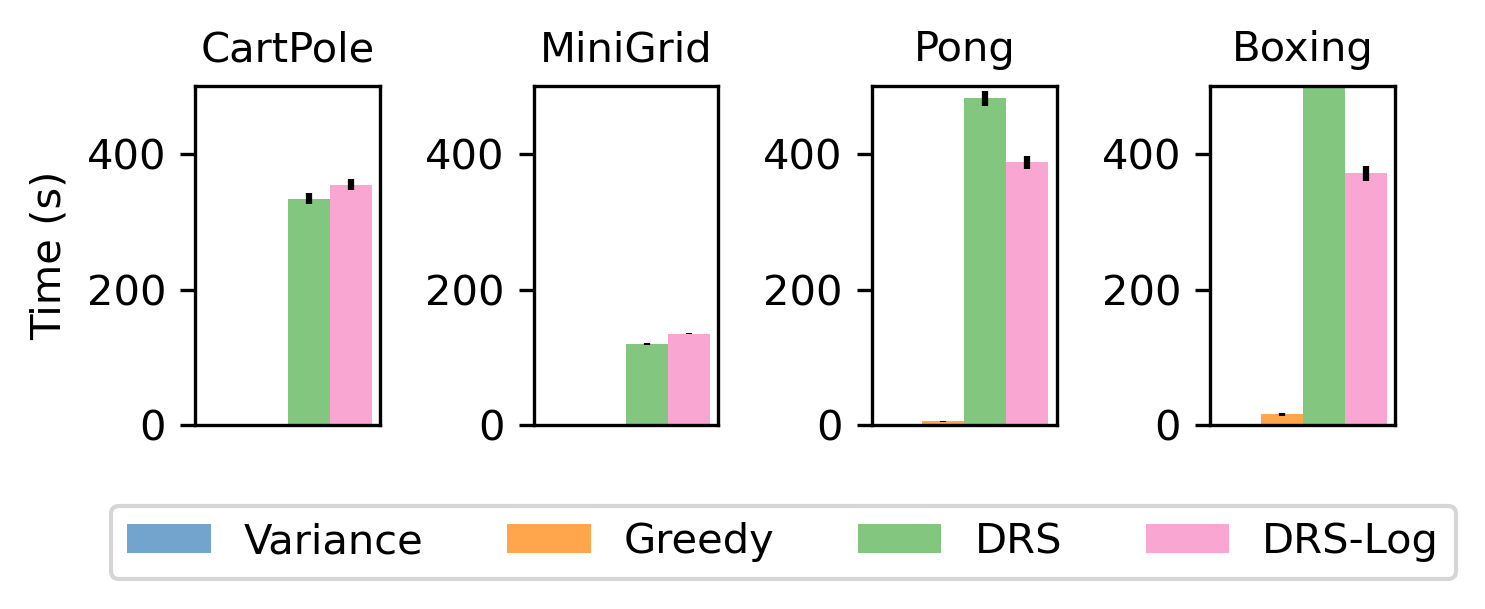

In [83]:
overall_format = {
    'figsize': (5, 2), 'style_size': style_size, 'has_grid': False,
    'y_lim':   [[[0, 500] for _ in range(4)]],
    'x_ticks': [[[[],[]] for _ in range(4)]],
    'label_size': 10, 'title_size': 10,
}
methods_dict_shifted = {0: 'Variance', 1: 'Greedy', 2: 'DRS', 3: 'DRS-Log'}
fig, ax = create_axes(
    (1, len(timing_envs)), overall_format,
    titles=[[name_to_nice[e] for e in timing_envs]],
    y_labels=[["Time (s)"] + [""] * (len(timing_envs) - 1)])
bar_format = {'color_palette': 'six_color', 'linewidth': 10, 'style_size': style_size}
plt.tight_layout()

for i in range(len(timing_envs)):
    plot_bar(ax[0][i], list(range(len(timing_perf[i]))),
             timing_perf[i], timing_std[i], methods_dict_shifted, bar_format)
    
legend_format = {
    'style_size': style_size, 'type': 'is_global', 'loc': 'lower left',
    'ncol': 6, 'bbox_to_anchor': (0.1, -0.1), 'fontsize': 10,
}
create_legend(fig, ax, (1, len(timing_envs)), legend_format)
fig.savefig("figures/timing.pdf", dpi=300, bbox_inches='tight')